<a href="https://colab.research.google.com/github/khushihirawat/post-disaster-assessment/blob/main/disaster_assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow import keras
import keras.ops as ops
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, precision_score, recall_score)

print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("TensorFlow:", tf.__version__)

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow: 2.20.0


In [ ]:
import kagglehub
path = kagglehub.dataset_download("kmader/satellite-images-of-hurricane-damage")

print("Path to dataset files:", path)

100%|██████████| 63.0M/63.0M [00:05<00:00, 12.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kmader/satellite-images-of-hurricane-damage/versions/1


In [ ]:
DATASET_ROOT = Path(path)

print("\nFull folder structure:")
for item in sorted(DATASET_ROOT.rglob('*')):
    if item.is_dir():
        images = list(item.glob('*.jpg')) + \
                 list(item.glob('*.png')) + \
                 list(item.glob('*.jpeg'))
        print(f"  {item.relative_to(DATASET_ROOT)}/ — {len(images)} images")


Full folder structure:
  test/ — 0 images
  test/damage/ — 1000 images
  test/no_damage/ — 1000 images
  test_another/ — 0 images
  test_another/damage/ — 8000 images
  test_another/no_damage/ — 1000 images
  train_another/ — 0 images
  train_another/damage/ — 5000 images
  train_another/no_damage/ — 5000 images
  validation_another/ — 0 images
  validation_another/damage/ — 1000 images
  validation_another/no_damage/ — 1000 images


block 2

In [ ]:
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 64
EPOCHS_P1 = 10         # Phase 1: frozen backbone
EPOCHS_P2 = 10         # Phase 2: fine-tuning
LR_P1 = 1e-4           # Phase 1 learning rate
LR_P2 = 1e-5           # Phase 2 learning rate
UNFREEZE_LAYERS = 50   # top layers to unfreeze in Phase 2 fine tuning
DROPOUT_RATE = 0.4
CBAM_RATIO = 8
CBAM_KERNEL = 7
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Dataset paths
DATASET_ROOT = Path(path)
TRAIN_DIR = DATASET_ROOT / 'train_another'
VAL_DIR = DATASET_ROOT / 'validation_another'
TEST_DIR = DATASET_ROOT / 'test'
TEST_IMB_DIR = DATASET_ROOT / 'test_another'

print(f"Train dir            : {TRAIN_DIR}")
print(f"Val dir              : {VAL_DIR}")
print(f"Test dir (balanced)  : {TEST_DIR}")
print(f"Test dir (imbalanced): {TEST_IMB_DIR}")

Train dir            : /root/.cache/kagglehub/datasets/kmader/satellite-images-of-hurricane-damage/versions/1/train_another
Val dir              : /root/.cache/kagglehub/datasets/kmader/satellite-images-of-hurricane-damage/versions/1/validation_another
Test dir (balanced)  : /root/.cache/kagglehub/datasets/kmader/satellite-images-of-hurricane-damage/versions/1/test
Test dir (imbalanced): /root/.cache/kagglehub/datasets/kmader/satellite-images-of-hurricane-damage/versions/1/test_another


block 3

DATASET EXPLORATION

train_another/
  damage          : 5000 images
  no_damage       : 5000 images

validation_another/
  damage          : 1000 images
  no_damage       : 1000 images

test (balanced)/
  damage          : 1000 images
  no_damage       : 1000 images

test_another (imb)/
  damage          : 8000 images
  no_damage       : 1000 images

CLASS BALANCE ANALYSIS — Training Set
Damage    : 5000 (50.0%)
No Damage : 5000 (50.0%)
Ratio     : 1.00:1

Dataset is balanced — class weighting not required


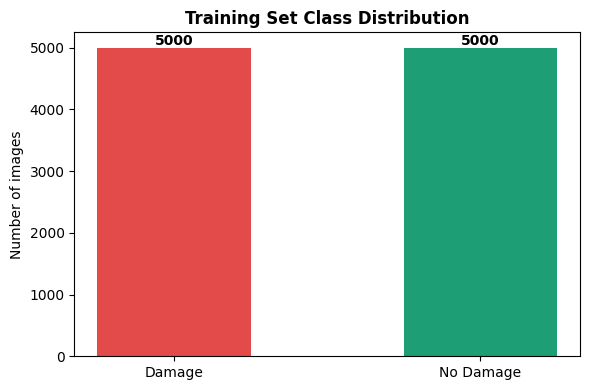

Class distribution figure saved


In [ ]:
print("=" * 65)
print("DATASET EXPLORATION")
print("=" * 65)

# Count images per class
splits = {
    'train_another' : TRAIN_DIR,
    'validation_another' : VAL_DIR,
    'test (balanced)' : TEST_DIR,
    'test_another (imb)' : TEST_IMB_DIR,
}

for split_name, split_path in splits.items():
    print(f"\n{split_name}/")
    for cls_dir in sorted(split_path.iterdir()):
        count = len(list(cls_dir.iterdir()))
        print(f"  {cls_dir.name:<15} : {count} images")

# Class balance analysis for training set
damage_count = len(list((TRAIN_DIR / 'damage').iterdir()))
no_damage_count = len(list((TRAIN_DIR / 'no_damage').iterdir()))
total = damage_count + no_damage_count
ratio = max(damage_count, no_damage_count) / min(damage_count, no_damage_count)

print("\n" + "=" * 65)
print("CLASS BALANCE ANALYSIS — Training Set")
print("=" * 65)
print(f"Damage    : {damage_count} ({damage_count/total*100:.1f}%)")
print(f"No Damage : {no_damage_count} ({no_damage_count/total*100:.1f}%)")
print(f"Ratio     : {ratio:.2f}:1")

# Compute class weights if imbalanced
if ratio > 1.5:
    print("\nImbalance detected — computing class weights")
    w_damage = (1 / damage_count)    * (total / 2.0)
    w_no_damage = (1 / no_damage_count) * (total / 2.0)
    class_weight = {0: w_damage, 1: w_no_damage}
    print(f"Class weights: {class_weight}")
else:
    print("\nDataset is balanced — class weighting not required")
    class_weight = None

# ── Visualise class distribution ──────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Damage', 'No Damage'],
              [damage_count, no_damage_count],
              color=['#E24B4A', '#1D9E75'], width=0.5)
ax.set_title('Training Set Class Distribution',
             fontweight='bold', fontsize=12)
ax.set_ylabel('Number of images')
for bar, count in zip(bars, [damage_count, no_damage_count]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 50,
            str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('figure_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Class distribution figure saved")

block 4


In [ ]:
print("=" * 65)
print("IMAGE PREPROCESSING & AUGMENTATION PIPELINE")
print("=" * 65)

# ── Contrast augmentation function ────────────────────────────
def augment_with_contrast(image):

    factor = np.random.uniform(0.8, 1.2)
    mean   = image.mean(axis=(0, 1), keepdims=True)
    image  = mean + factor * (image - mean)
    return np.clip(image, 0, 255).astype('float32')

# ── Training augmentation ──────────────────────────────────────

train_datagen = ImageDataGenerator(
    preprocessing_function = augment_with_contrast,
    horizontal_flip = True,
    vertical_flip = True,
    rotation_range = 20,
    zoom_range = 0.1,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    brightness_range = [0.8, 1.2],
)

val_test_datagen = ImageDataGenerator()

# ── Data generators ────────────────────────────────────────────
train_generator = train_datagen.flow_from_directory(
    str(TRAIN_DIR),
    target_size = IMAGE_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary',
    seed = SEED,
    shuffle = True
)

val_generator = val_test_datagen.flow_from_directory(
    str(VAL_DIR),
    target_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    class_mode  = 'binary',
    shuffle = False
)

print(f"Class mapping : {train_generator.class_indices}")
print(f"Train samples : {train_generator.samples}")
print(f"Val samples   : {val_generator.samples}")

STEP 1 — IMAGE PREPROCESSING & AUGMENTATION PIPELINE
Found 10000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Class mapping : {'damage': 0, 'no_damage': 1}
Train samples : 10000
Val samples   : 2000


block 5

DATASET VISUALISATION


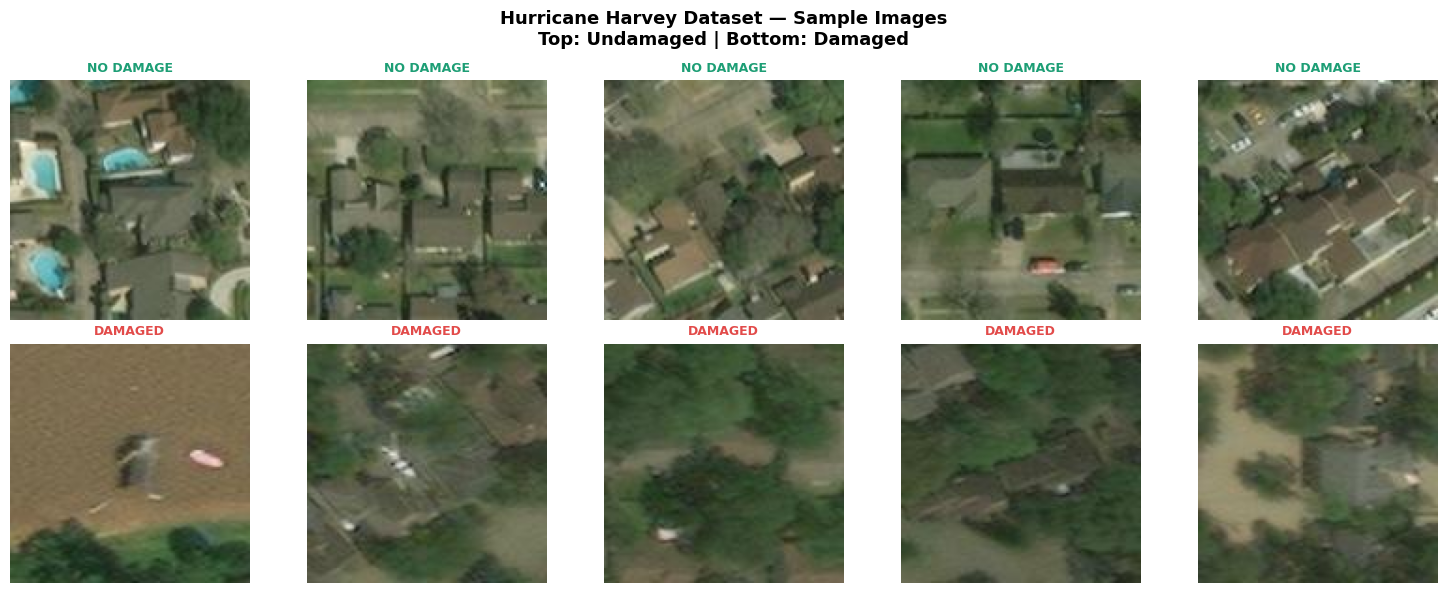

Figure 1 saved — dataset samples


In [ ]:
print("=" * 65)
print("DATASET VISUALISATION")
print("=" * 65)

def show_samples(train_dir, n=5):
    damage_dir = train_dir / 'damage'
    no_damage_dir = train_dir / 'no_damage'

    damage_imgs = random.sample(list(damage_dir.iterdir()), n)
    no_damage_imgs = random.sample(list(no_damage_dir.iterdir()), n)

    fig, axes = plt.subplots(2, n, figsize=(15, 6))
    fig.suptitle('Hurricane Harvey Dataset — Sample Images\n'
                 'Top: Undamaged | Bottom: Damaged',
                 fontsize=13, fontweight='bold')

    for i in range(n):
        img = Image.open(no_damage_imgs[i])
        axes[0, i].imshow(img)
        axes[0, i].set_title('NO DAMAGE', color='#1D9E75',
                              fontweight='bold', fontsize=9)
        axes[0, i].axis('off')

        img = Image.open(damage_imgs[i])
        axes[1, i].imshow(img)
        axes[1, i].set_title('DAMAGED', color='#E24B4A',
                              fontweight='bold', fontsize=9)
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.savefig('figure1_dataset_samples.png', dpi=150,
                bbox_inches='tight')
    plt.show()
    print("Figure 1 saved — dataset samples")

show_samples(TRAIN_DIR)

block 6

In [ ]:
print("=" * 65)
print("CBAM ATTENTION MODULE")
print("=" * 65)

def channel_attention(input_feature, ratio=8):
    channel = input_feature.shape[-1]

    shared_dense_one = layers.Dense(channel // ratio,
                                     activation='relu',
                                     use_bias=False,
                                     name='ca_dense_1')
    shared_dense_two = layers.Dense(channel,
                                     use_bias=False,
                                     name='ca_dense_2')

    # average pool path
    avg_pool = layers.GlobalAveragePooling2D(name='ca_avg')(input_feature)
    avg_pool = layers.Reshape((1, 1, channel))(avg_pool)
    avg_pool = shared_dense_one(avg_pool)
    avg_pool = shared_dense_two(avg_pool)

    # max pool path
    max_pool = layers.GlobalMaxPooling2D(name='ca_max')(input_feature)
    max_pool = layers.Reshape((1, 1, channel))(max_pool)
    max_pool = shared_dense_one(max_pool)
    max_pool = shared_dense_two(max_pool)

    # combine
    attention = layers.Add(name='ca_add')([avg_pool, max_pool])
    attention = layers.Activation('sigmoid', name='ca_sigmoid')(attention)

    # rescale input by channel weights
    return layers.Multiply(name='ca_output')([input_feature, attention])


def spatial_attention(input_feature, kernel_size=7):

    # channel-wise statistics
    avg_pool = ops.mean(input_feature, axis=-1, keepdims=True)
    max_pool = ops.max(input_feature,  axis=-1, keepdims=True)

    concat = layers.Concatenate(axis=-1,
                                 name='sa_concat')([avg_pool, max_pool])

    attention = layers.Conv2D(
        filters     = 1,
        kernel_size = kernel_size,
        padding     = 'same',
        activation  = 'sigmoid',
        use_bias    = False,
        name        = 'sa_conv'
    )(concat)

    return layers.Multiply(name='sa_output')([input_feature, attention])


def cbam_block(input_feature, ratio=8, kernel_size=7):
    x = channel_attention(input_feature, ratio)
    x = spatial_attention(x, kernel_size)
    return x


# ── Sanity check ───────────────────────────────────────────────
test_in = keras.Input(shape=(4, 4, 32))
test_out = cbam_block(test_in, ratio=4, kernel_size=3)
test_m = keras.Model(test_in, test_out)
print(f"CBAM sanity check passed")
print(f"  Input  shape : {test_m.input_shape}")
print(f"  Output shape : {test_m.output_shape}")
del test_m

CBAM ATTENTION MODULE
CBAM sanity check passed
  Input  shape : (None, 4, 4, 32)
  Output shape : (None, 4, 4, 32)


block 7

In [ ]:
print("=" * 65)
print("BUILDING COMPLETE MODEL")
print("=" * 65)

from keras.applications import EfficientNetB0
import keras

keras.backend.clear_session()

base_model = EfficientNetB0(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (128, 128, 3)
)
base_model.trainable = False
print(f"EfficientNetB0 loaded — total layers: {len(base_model.layers)}")

# build model
inputs = keras.Input(shape=(128, 128, 3), name='input_image')
x = layers.Rescaling(scale=1./127.5, offset=-1,
                      name='efficientnet_preprocess')(inputs)

x = base_model(inputs, training=False)
print(f"Backbone output shape : {x.shape}")

# CBAM
x = cbam_block(x, ratio=CBAM_RATIO, kernel_size=CBAM_KERNEL)
print(f"After CBAM shape      : {x.shape}")

#global feature aggregation
x = layers.GlobalAveragePooling2D(name='gap')(x)
x = layers.BatchNormalization(name='batch_norm')(x)
x = layers.Dense(256, activation='gelu', name='dense_256')(x)
x = layers.Dropout(DROPOUT_RATE, name='dropout')(x)
x = layers.Dense(64,  activation='gelu', name='dense_64')(x)

# binary output
outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

model = keras.Model(inputs, outputs, name='EfficientNetB0_CBAM')

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LR_P1),
    loss      = 'binary_crossentropy',
    metrics   = [
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

print("\nMODEL BUILT SUCCESSFULLY")
print(f"Total parameters : {model.count_params():,}")
print(f"Input shape      : {model.input_shape}")
print(f"Output shape     : {model.output_shape}")

BUILDING COMPLETE MODEL
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
EfficientNetB0 loaded — total layers: 238
Backbone output shape : (None, 4, 4, 1280)
After CBAM shape      : (None, 4, 4, 1280)

MODEL BUILT SUCCESSFULLY
Total parameters : 4,808,838
Input shape      : (None, 128, 128, 3)
Output shape     : (None, 1)


block 8

In [ ]:
callbacks_p1 = [
    ModelCheckpoint(
        filepath       = 'best_model_p1.keras',
        monitor        = 'val_auc',
        save_best_only = True,
        mode           = 'max',
        verbose        = 1
    ),
    EarlyStopping(
        monitor              = 'val_auc',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-7,
        verbose  = 1
    )
]

callbacks_p2 = [
    ModelCheckpoint(
        filepath       = 'best_model_p2.keras',
        monitor        = 'val_auc',
        save_best_only = True,
        mode           = 'max',
        verbose        = 1
    ),
    EarlyStopping(
        monitor              = 'val_auc',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-7,
        verbose  = 1
    )
]
print("Callbacks set for phase 1 and phase 2")

Callbacks set for phase 1 and phase 2


block 9

In [ ]:
print("=" * 65)
print("PHASE 1 — Head + CBAM | Backbone FROZEN")
print(f"Epochs: {EPOCHS_P1} | LR: {LR_P1} | Batch: {BATCH_SIZE}")
print("=" * 65)

p1_start = time.time()

history_p1 = model.fit(
    train_generator,
    epochs= EPOCHS_P1,
    validation_data = val_generator,
    class_weight = class_weight,
    callbacks = callbacks_p1,
    verbose = 1
)

p1_time= time.time() - p1_start
p1_best_acc = max(history_p1.history['val_accuracy'])
p1_best_auc = max(history_p1.history['val_auc'])

print(f"\nPhase 1 complete")
print(f"Best Val Accuracy : {p1_best_acc*100:.2f}%")
print(f"Best Val AUC      : {p1_best_auc:.4f}")
print(f"Training time     : {p1_time/60:.1f} minutes")

PHASE 1 — Head + CBAM | Backbone FROZEN
Epochs: 10 | LR: 0.0001 | Batch: 64
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.6776 - auc: 0.7438 - loss: 0.5901 - precision: 0.6559 - recall: 0.7529
Epoch 1: val_auc improved from None to 0.93189, saving model to best_model_p1.keras

Epoch 1: finished saving model to best_model_p1.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 125s 587ms/step - accuracy: 0.7634 - auc: 0.8487 - loss: 0.4823 - precision: 0.7472 - recall: 0.7962 - val_accuracy: 0.8590 - val_auc: 0.9319 - val_loss: 0.5262 - val_precision: 0.8693 - val_recall: 0.8450 - learning_rate: 1.0000e-04
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.8527 - auc: 0.9310 - loss: 0.3359 - precision: 0.8433 - recall: 0.8638
Epoch 2: val_auc improved from 0.93189 to 0.96272, saving model to best_model_p1.keras

Epoch 2: finished saving model to best_model_p1.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 390ms/step - accuracy: 0.8611 - auc: 0.9359 - loss: 0.3233 - precisio

block 10

In [ ]:
print("=" * 65)
print(f"PHASE 2 — Fine-tuning top {UNFREEZE_LAYERS} EfficientNet layers")
print(f"Epochs: {EPOCHS_P2} | LR: {LR_P2}")
print("=" * 65)


model = keras.models.load_model('best_model_p1.keras')
print("Phase 1 model loaded successfully")

# unfreeze top UNFREEZE_LAYERS of EfficientNetB0
for layer in model.layers:
    if 'efficientnetb0' in layer.name.lower():
        layer.trainable = True
        for sublayer in layer.layers[:-UNFREEZE_LAYERS]:
            sublayer.trainable = False
        trainable = sum(1 for l in layer.layers if l.trainable)
        frozen = sum(1 for l in layer.layers if not l.trainable)
        print(f"EfficientNet trainable layers : {trainable}")
        print(f"EfficientNet frozen layers    : {frozen}")
        break

# recompile at a lower learning rate
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LR_P2),
    loss = 'binary_crossentropy',
    metrics = ['accuracy',
                keras.metrics.AUC(name='auc'),
                keras.metrics.Precision(name='precision'),
                keras.metrics.Recall(name='recall')
    ]
)

p2_start = time.time()

history_p2 = model.fit(
    train_generator,
    epochs          = EPOCHS_P2,
    validation_data = val_generator,
    class_weight    = class_weight,
    callbacks       = callbacks_p2,
    verbose         = 1
)

p2_time     = time.time() - p2_start
p2_best_acc = max(history_p2.history['val_accuracy'])
p2_best_auc = max(history_p2.history['val_auc'])

print(f"\nPhase 2 complete")
print(f"Best Val Accuracy : {p2_best_acc*100:.2f}%")
print(f"Best Val AUC      : {p2_best_auc:.4f}")
print(f"Phase 2 time      : {p2_time/60:.1f} minutes")
print(f"Total training    : {(p1_time+p2_time)/60:.1f} minutes")

PHASE 2 — Fine-tuning top 50 EfficientNet layers
Epochs: 10 | LR: 1e-05
Phase 1 model loaded successfully
EfficientNet trainable layers : 50
EfficientNet frozen layers    : 188
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.8284 - auc: 0.9078 - loss: 0.3855 - precision: 0.8243 - recall: 0.8367
Epoch 1: val_auc improved from None to 0.97185, saving model to best_model_p2.keras

Epoch 1: finished saving model to best_model_p2.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 128s 588ms/step - accuracy: 0.8381 - auc: 0.9176 - loss: 0.3643 - precision: 0.8350 - recall: 0.8428 - val_accuracy: 0.9110 - val_auc: 0.9719 - val_loss: 0.2172 - val_precision: 0.9152 - val_recall: 0.9060 - learning_rate: 1.0000e-05
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.8725 - auc: 0.9464 - loss: 0.2959 - precision: 0.8795 - recall: 0.8641
Epoch 2: val_auc did not improve from 0.97185
157/157 ━━━━━━━━━━━━━━━━━━━━ 66s 419ms/step - accuracy: 0.8771 - auc: 0.9501 - loss: 0.2856 - pre

block 11

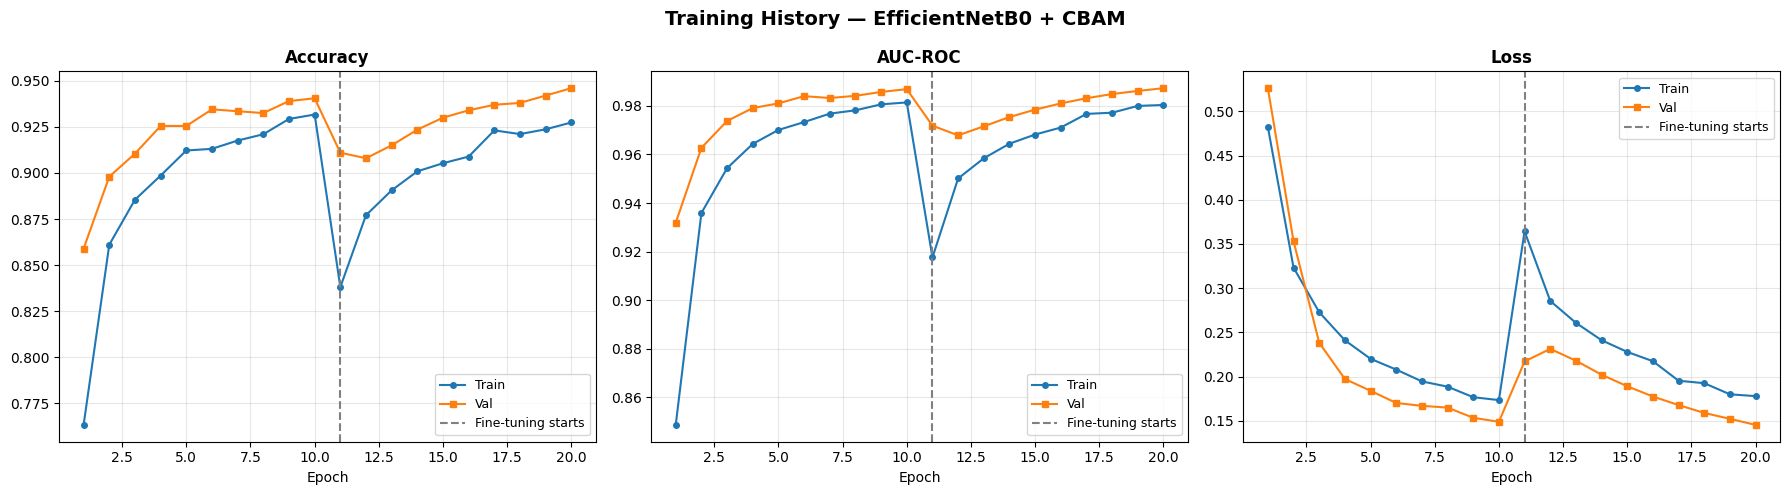

Figure 3 saved — training curves


In [ ]:
# combine both phase histories
acc      = history_p1.history['accuracy'] + history_p2.history['accuracy']
val_acc  = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
auc      = history_p1.history['auc'] + history_p2.history['auc']
val_auc  = history_p1.history['val_auc'] + history_p2.history['val_auc']
loss     = history_p1.history['loss'] + history_p2.history['loss']
val_loss = history_p1.history['val_loss'] + history_p2.history['val_loss']

epochs_total = range(1, len(acc) + 1)
phase2_start = len(history_p1.history['accuracy']) + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History — EfficientNetB0 + CBAM',
             fontsize=14, fontweight='bold')

for ax, tr, vl, title in zip(
    axes,
    [acc,     auc,     loss],
    [val_acc, val_auc, val_loss],
    ['Accuracy', 'AUC-ROC', 'Loss']
):
    ax.plot(epochs_total, tr, label='Train', marker='o', markersize=4)
    ax.plot(epochs_total, vl, label='Val',   marker='s', markersize=4)
    ax.axvline(x=phase2_start, color='gray', linestyle='--',
               linewidth=1.5, label='Fine-tuning starts')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure3_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved — training curves")

block 12

In [ ]:
print("=" * 65)
print("EXPLAINABILITY MODULE")
print("=" * 65)

model = keras.models.load_model('best_model_p2.keras')
print(f"Model loaded | Input: {model.input_shape} | Output: {model.output_shape}")

# ── Find last Conv2D inside EfficientNetB0 ─────────────────────
def get_last_conv_layer(model):
    for layer in model.layers:
        if 'efficientnetb0' in layer.name.lower():
            for sublayer in reversed(layer.layers):
                if isinstance(sublayer, keras.layers.Conv2D):
                    return layer, sublayer
    return None, None

efficientnet_layer, last_conv = get_last_conv_layer(model)
print(f"Last conv layer: {last_conv.name}")

# ── load image as raw pixels [0,255] ───────────────────
def load_image(img_path):
    img = Image.open(img_path).resize(IMAGE_SIZE).convert('RGB')
    return np.expand_dims(np.array(img, dtype='float32'), axis=0)

# ── overlay heatmap on image ──────────────────────────
def heatmap_to_overlay(img_path, heatmap, alpha=0.45):
    img_np  = np.array(Image.open(img_path).resize(IMAGE_SIZE).convert('RGB'))
    cam_up  = np.array(Image.fromarray(np.uint8(255 * heatmap))
                       .resize(IMAGE_SIZE, Image.LANCZOS))
    cam_rgb = np.uint8(plt.cm.jet(cam_up / 255.0)[:, :, :3] * 255)
    overlay = np.uint8(img_np * (1 - alpha) + cam_rgb * alpha)
    return img_np, overlay

# ── Grad-CAM ───────────────────────────────────────────────────
def compute_gradcam(model, img_array, efficientnet_layer, last_conv):

    grad_model = keras.Model(
        inputs  = efficientnet_layer.input,
        outputs = [last_conv.output, efficientnet_layer.output]
    )

    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, features = grad_model(img_tensor, training=False)
        tape.watch(conv_outputs)
        x    = model.get_layer('gap')(features)
        x    = model.get_layer('batch_norm')(x, training=False)
        x    = model.get_layer('dense_256')(x)
        x    = model.get_layer('dropout')(x, training=False)
        x    = model.get_layer('dense_64')(x)
        pred = model.get_layer('output')(x)
        loss = pred[:, 0]

    grads        = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# ── Score-CAM ──────────────────────────────────────────────────
def compute_scorecam(model, img_array, efficientnet_layer, last_conv,
                     max_channels=50):

    act_model   = keras.Model(
        inputs  = efficientnet_layer.input,
        outputs = last_conv.output
    )
    activations = act_model.predict(
        tf.cast(img_array, tf.float32), verbose=0
    )[0]

    top_channels = np.argsort(
        activations.mean(axis=(0, 1))
    )[-max_channels:]

    scores = np.zeros(len(top_channels))
    for idx, ch in enumerate(top_channels):
        act_map        = activations[:, :, ch]
        a_min, a_max   = act_map.min(), act_map.max()
        if a_max - a_min < 1e-8:
            continue

        act_norm = (act_map - a_min) / (a_max - a_min)
        act_up   = np.array(
            Image.fromarray(act_norm).resize(IMAGE_SIZE, Image.LANCZOS)
        )

        masked         = img_array[0] * act_up[:, :, np.newaxis]
        masked         = np.expand_dims(masked, 0).astype('float32')
        scores[idx]    = float(model.predict(masked, verbose=0)[0][0])

    # weighted sum of activation maps
    cam = sum(
        scores[idx] * activations[:, :, ch]
        for idx, ch in enumerate(top_channels)
    )
    cam = np.maximum(cam, 0)
    if cam.max() > 0:
        cam = cam / cam.max()
    return cam

print(f"Last conv layer : {last_conv.name}")

EXPLAINABILITY MODULE
Model loaded | Input: (None, 128, 128, 3) | Output: (None, 1)
Last conv layer: top_conv
Last conv layer : top_conv


block 13

EXPLAINABILITY — Grad-CAM vs Score-CAM Side-by-Side
  Sample 1/4 — computing Grad-CAM...
  Sample 1/4 — computing Score-CAM (top 50 channels)...
  Sample 2/4 — computing Grad-CAM...
  Sample 2/4 — computing Score-CAM (top 50 channels)...
  Sample 3/4 — computing Grad-CAM...
  Sample 3/4 — computing Score-CAM (top 50 channels)...
  Sample 4/4 — computing Grad-CAM...
  Sample 4/4 — computing Score-CAM (top 50 channels)...


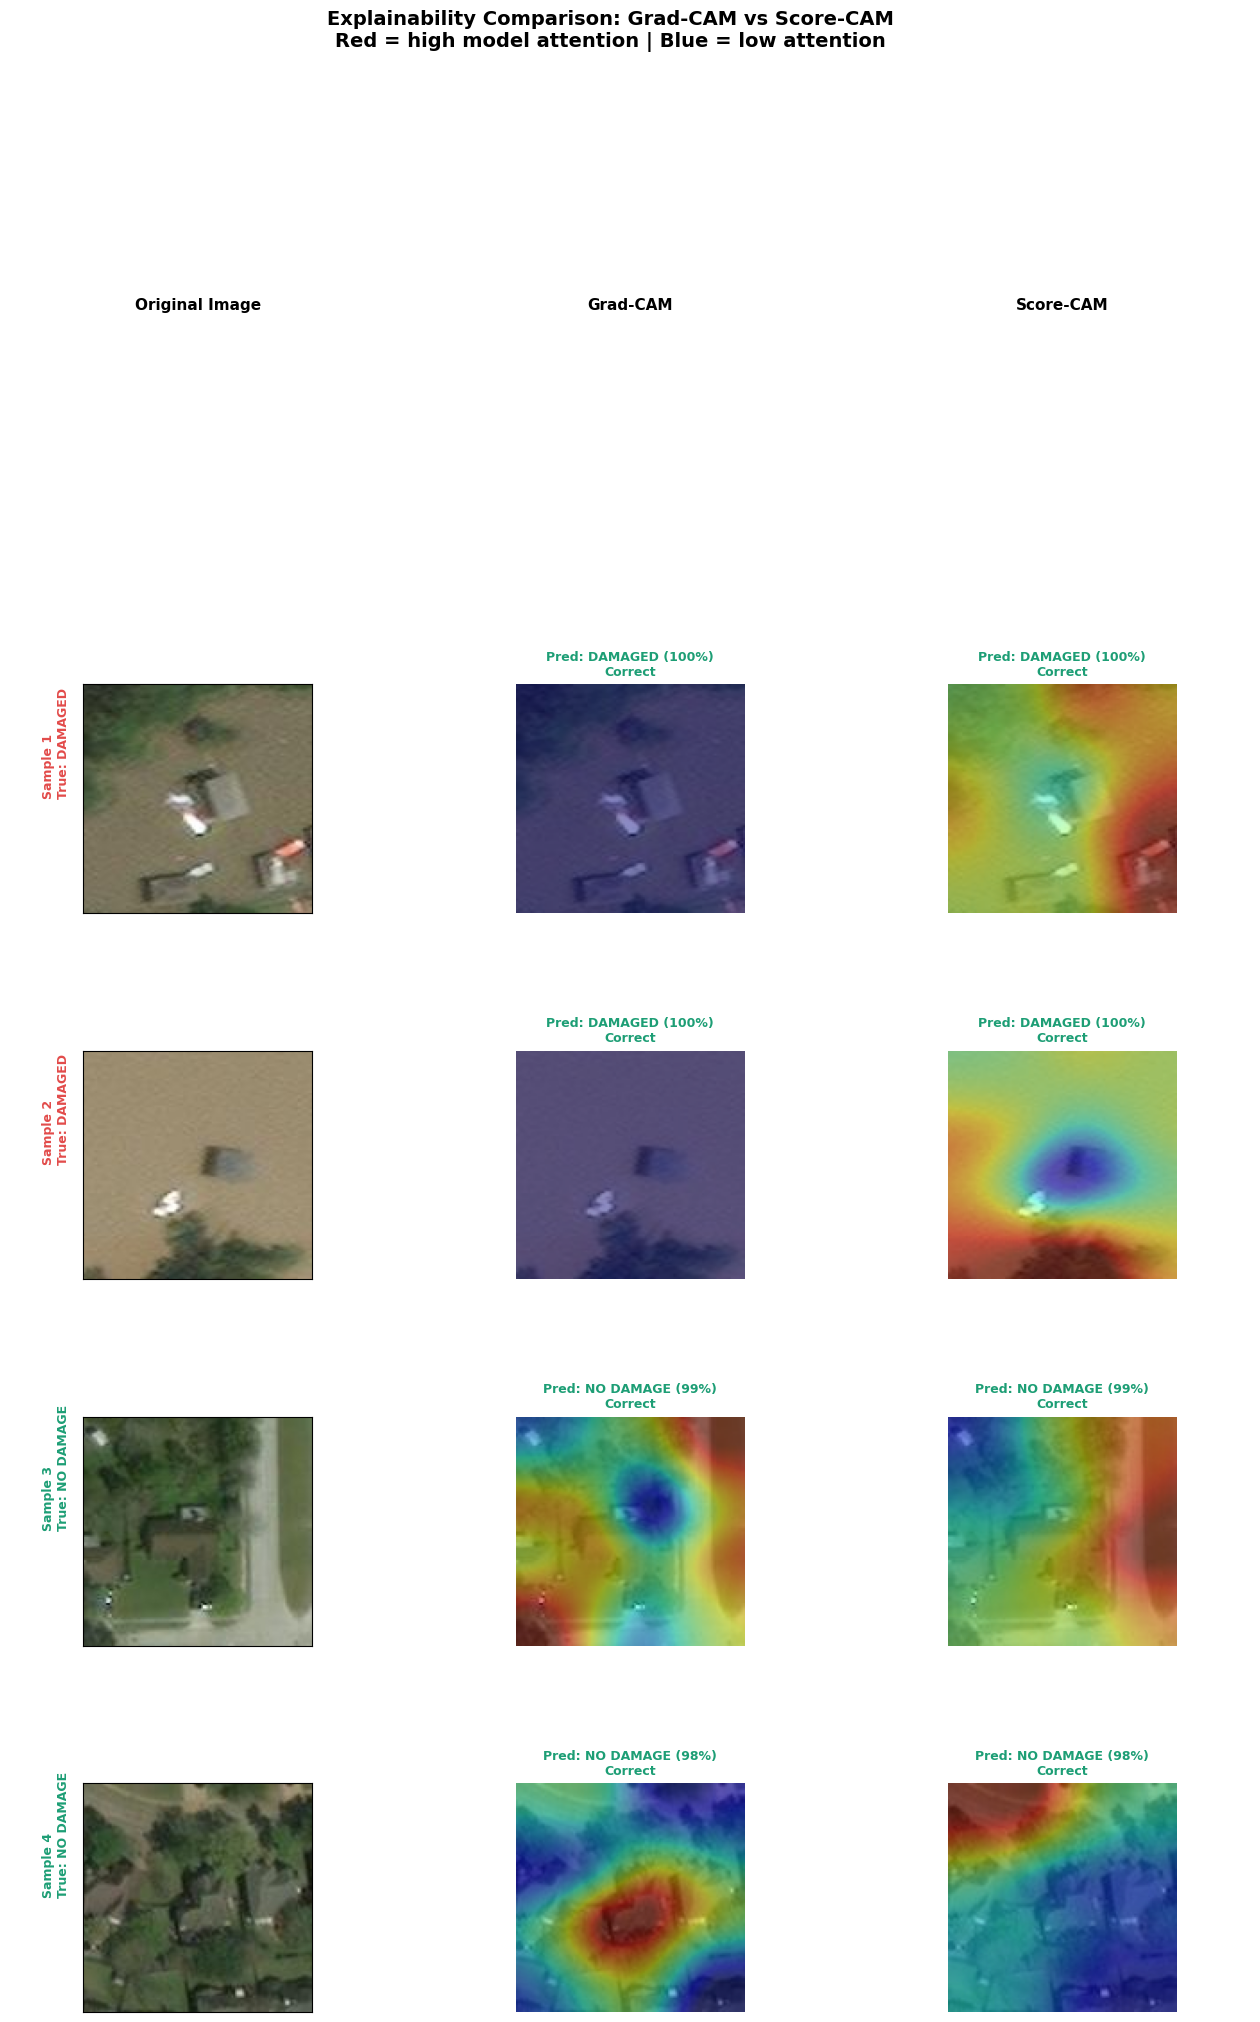

Figure 7 saved — Grad-CAM vs Score-CAM comparison


In [ ]:
print("=" * 65)
print("EXPLAINABILITY — Grad-CAM vs Score-CAM Side-by-Side")
print("=" * 65)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

compare_samples = (
    random.sample(list((TEST_DIR / 'damage').iterdir()),    2) +
    random.sample(list((TEST_DIR / 'no_damage').iterdir()), 2)
)
compare_labels = ['DAMAGED', 'DAMAGED', 'NO DAMAGE', 'NO DAMAGE']
compare_colors = ['#E24B4A', '#E24B4A', '#1D9E75',   '#1D9E75']

# 5 rows: row 0 = column headers, rows 1-4 = one sample each
fig = plt.figure(figsize=(16, 22))
fig.suptitle(
    'Explainability Comparison: Grad-CAM vs Score-CAM\n'
    'Red = high model attention | Blue = low attention',
    fontsize=14, fontweight='bold', y=1.02
)
gs = gridspec.GridSpec(5, 3, figure=fig, hspace=0.6, wspace=0.15)

# ── Column headers in row 0 ────────────────────────────────────
for col, title in enumerate(
    ['Original Image', 'Grad-CAM', 'Score-CAM']
):
    ax = fig.add_subplot(gs[0, col])
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.axis('off')

# ── Sample rows 1–4 ───────────────────────────────────────────
for row, (img_path, true_label, colour) in enumerate(
    zip(compare_samples, compare_labels, compare_colors), start=1
):
    img_array = load_image(img_path)

    print(f"  Sample {row}/4 — computing Grad-CAM...")
    gradcam_heat  = compute_gradcam(
        model, img_array, efficientnet_layer, last_conv
    )
    print(f"  Sample {row}/4 — computing Score-CAM (top 50 channels)...")
    scorecam_heat = compute_scorecam(
        model, img_array, efficientnet_layer, last_conv,
        max_channels=50
    )

    original, gc_overlay = heatmap_to_overlay(img_path, gradcam_heat)
    _,        sc_overlay = heatmap_to_overlay(img_path, scorecam_heat)

    pred_prob  = float(model.predict(img_array, verbose=0)[0][0])
    pred_label = 'NO DAMAGE' if pred_prob > 0.5 else 'DAMAGED'
    confidence = pred_prob   if pred_prob > 0.5 else 1 - pred_prob
    correct    = pred_label == true_label
    res_col    = '#1D9E75'   if correct else '#E24B4A'

    # col 0: original
    ax0 = fig.add_subplot(gs[row, 0])
    ax0.imshow(original)
    ax0.set_ylabel(f'Sample {row}\nTrue: {true_label}',
                   color=colour, fontweight='bold', fontsize=9, ha='left', labelpad=10)
    ax0.set_xticks([]); ax0.set_yticks([])

    # col 1: Grad-CAM
    ax1 = fig.add_subplot(gs[row, 1])
    ax1.imshow(gc_overlay)
    ax1.set_title(
        f'Pred: {pred_label} ({confidence*100:.0f}%)\n'
        f'{"Correct" if correct else "Wrong"}',
        color=res_col, fontsize=9, fontweight='bold'
    )
    ax1.axis('off')

    # col 2: Score-CAM
    ax2 = fig.add_subplot(gs[row, 2])
    ax2.imshow(sc_overlay)
    ax2.set_title(
        f'Pred: {pred_label} ({confidence*100:.0f}%)\n'
        f'{"Correct" if correct else "Wrong"}',
        color=res_col, fontsize=9, fontweight='bold'
    )
    ax2.axis('off')

plt.savefig('figure7_gradcam_vs_scorecam.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7 saved — Grad-CAM vs Score-CAM comparison")

block 14


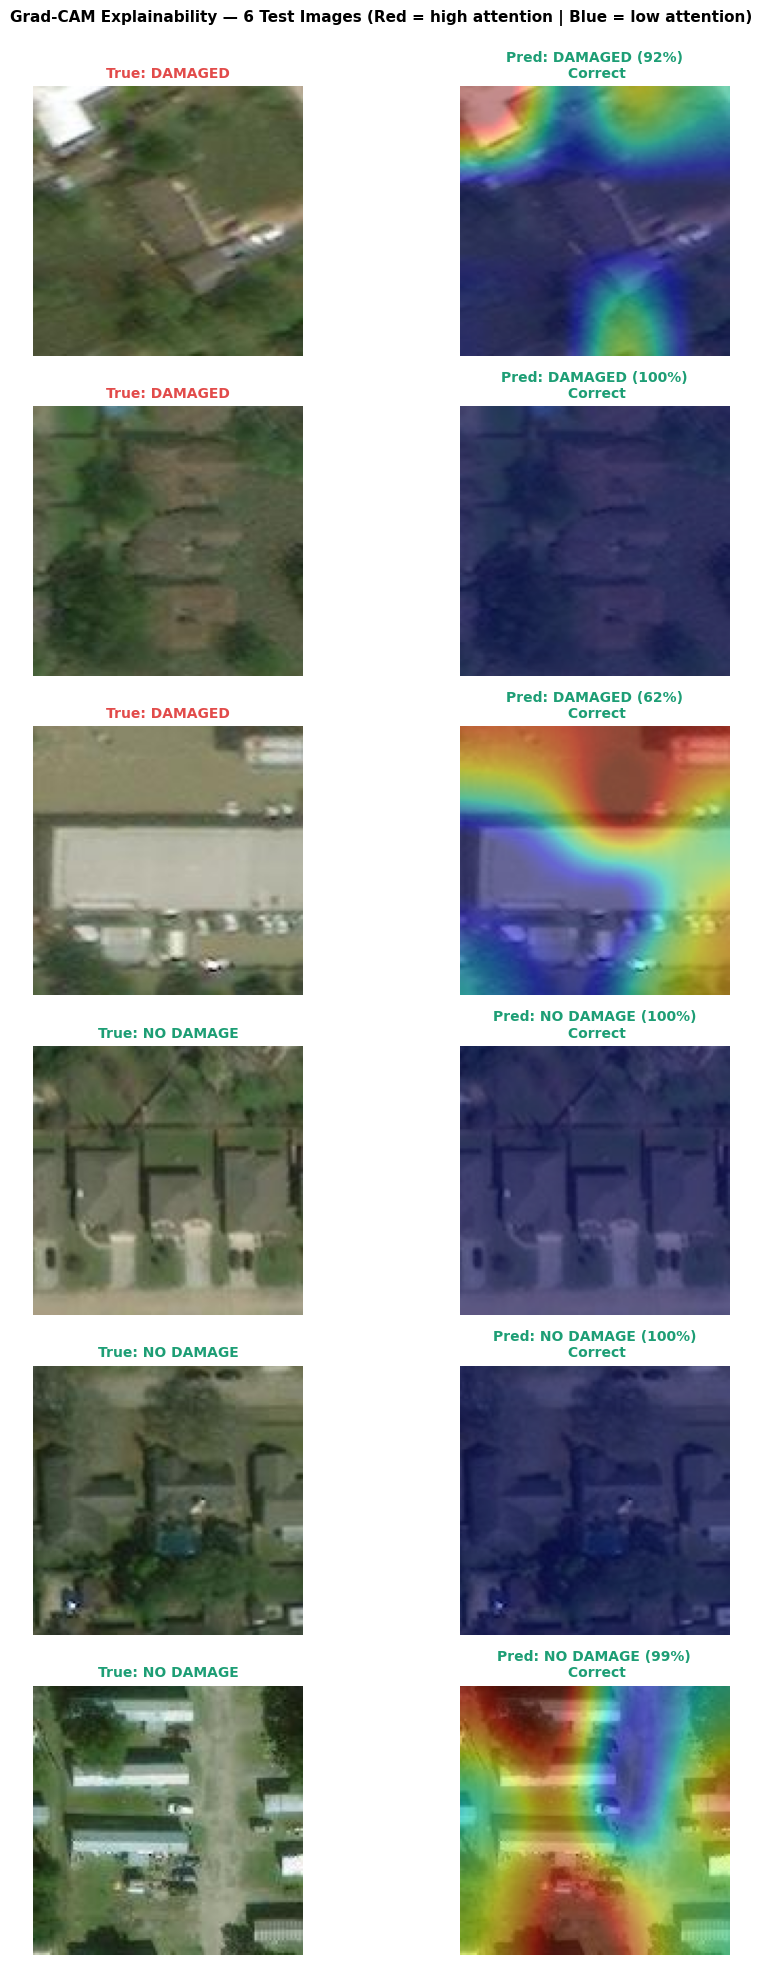

Figure 7b saved — Grad-CAM grid


In [ ]:
damage_s    = random.sample(list((TEST_DIR / 'damage').iterdir()),    3)
no_damage_s = random.sample(list((TEST_DIR / 'no_damage').iterdir()), 3)
all_samples = (
    [(p, 'DAMAGED',   '#E24B4A') for p in damage_s] +
    [(p, 'NO DAMAGE', '#1D9E75') for p in no_damage_s]
)

fig, axes = plt.subplots(6, 2, figsize=(10, 20))
fig.suptitle(
    'Grad-CAM Explainability — 6 Test Images (Red = high attention | Blue = low attention)\n\n',
    fontsize=11, fontweight='bold'
)

for i, (img_path, true_label, colour) in enumerate(all_samples):
    img_array  = load_image(img_path)
    heatmap    = compute_gradcam(model, img_array,
                                  efficientnet_layer, last_conv)
    original, overlay = heatmap_to_overlay(img_path, heatmap)

    pred_prob  = float(model.predict(img_array, verbose=0)[0][0])
    pred_label = 'NO DAMAGE' if pred_prob > 0.5 else 'DAMAGED'
    confidence = pred_prob   if pred_prob > 0.5 else 1 - pred_prob
    correct    = pred_label == true_label

    axes[i, 0].imshow(original)
    axes[i, 0].set_title(f'True: {true_label}',
                          color=colour, fontweight='bold', fontsize=10)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title(
        f'Pred: {pred_label} ({confidence*100:.0f}%)\n'
        f'{" Correct" if correct else " Wrong"}',
        color='#1D9E75' if correct else '#E24B4A',
        fontweight='bold', fontsize=10
    )
    axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig('figure7b_gradcam_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7b saved — Grad-CAM grid")

block 15

In [ ]:
print("=" * 65)
print("PERFORMANCE EVALUATION")
print("Pipeline: Accuracy, Precision, Recall, F1, ROC-AUC")
print("=" * 65)

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report

test_datagen = ImageDataGenerator()

# ── Balanced test set ──────────────────────────────────────────
test_gen = test_datagen.flow_from_directory(
    str(TEST_DIR), target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)
y_probs   = model.predict(test_gen, verbose=1)
y_pred    = (y_probs > 0.5).astype(int).flatten()
y_true    = test_gen.classes
class_names = list(test_gen.class_indices.keys())

test_acc  = np.mean(y_pred == y_true) * 100
test_auc  = roc_auc_score(y_true, y_probs)
test_f1   = f1_score(y_true, y_pred)
test_prec = precision_score(y_true, y_pred)
test_rec  = recall_score(y_true, y_pred)

print("\n BALANCED TEST SET ")
print(f"Accuracy  : {test_acc:.2f}%")
print(f"Precision : {test_prec:.4f}")
print(f"Recall    : {test_rec:.4f}")
print(f"F1-Score  : {test_f1:.4f}")
print(f"AUC-ROC   : {test_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_true, y_pred,
                             target_names=class_names))

# ── Imbalanced test set ────────────────────────────────────────
test_imb_gen = test_datagen.flow_from_directory(
    str(TEST_IMB_DIR), target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)
y_probs_imb = model.predict(test_imb_gen, verbose=1)
y_pred_imb  = (y_probs_imb > 0.5).astype(int).flatten()
y_true_imb  = test_imb_gen.classes

test_acc_imb  = np.mean(y_pred_imb == y_true_imb) * 100
test_auc_imb  = roc_auc_score(y_true_imb, y_probs_imb)
test_f1_imb   = f1_score(y_true_imb, y_pred_imb)

print("\n IMBALANCED TEST SET (8:1 ratio) ")
print(f"Accuracy  : {test_acc_imb:.2f}%")
print(f"F1-Score  : {test_f1_imb:.4f}")
print(f"AUC-ROC   : {test_auc_imb:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_true_imb, y_pred_imb,
                             target_names=class_names))

# ── Comparison table ───────────────────────────────────────────
print("\n CROSS-DISTRIBUTION COMPARISON ")
print(f"{'Metric':<15} {'Balanced':>12} {'Imbalanced':>12} {'Drop':>10}")
print("-" * 52)
print(f"{'Accuracy':<15} {test_acc:>12.2f} {test_acc_imb:>12.2f} {test_acc-test_acc_imb:>+10.2f}")
print(f"{'AUC-ROC':<15} {test_auc:>12.4f} {test_auc_imb:>12.4f} {test_auc-test_auc_imb:>+10.4f}")
print(f"{'F1-Score':<15} {test_f1:>12.4f} {test_f1_imb:>12.4f} {test_f1-test_f1_imb:>+10.4f}")

PERFORMANCE EVALUATION
Pipeline: Accuracy, Precision, Recall, F1, ROC-AUC
Found 2000 images belonging to 2 classes.
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step

 BALANCED TEST SET 
Accuracy  : 93.95%
Precision : 0.9339
Recall    : 0.9460
F1-Score  : 0.9399
AUC-ROC   : 0.9872

Classification Report:
              precision    recall  f1-score   support

      damage       0.95      0.93      0.94      1000
   no_damage       0.93      0.95      0.94      1000

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000

Found 9000 images belonging to 2 classes.
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step

 IMBALANCED TEST SET (8:1 ratio) 
Accuracy  : 93.49%
F1-Score  : 0.7592
AUC-ROC   : 0.9837

Classification Report:
              precision    recall  f1-score   support

      damage       0.99      0.94      0.96      8000
   no_damage       0.64      0.92      0.76      1000

    accuracy

block 16

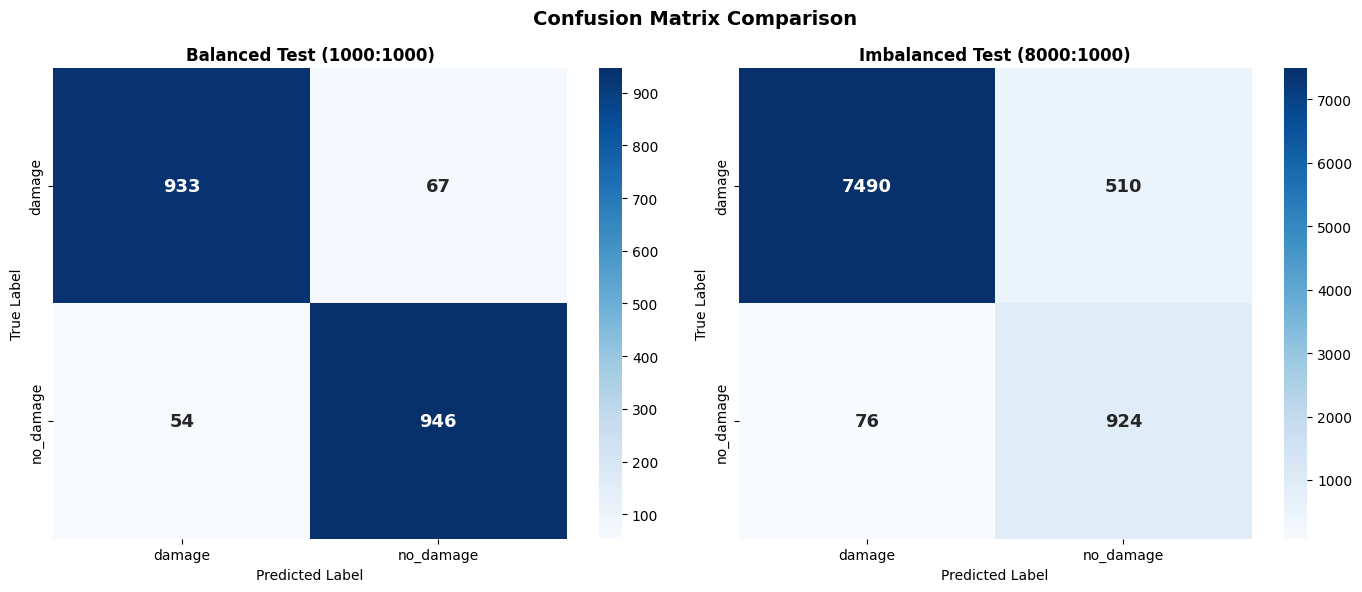

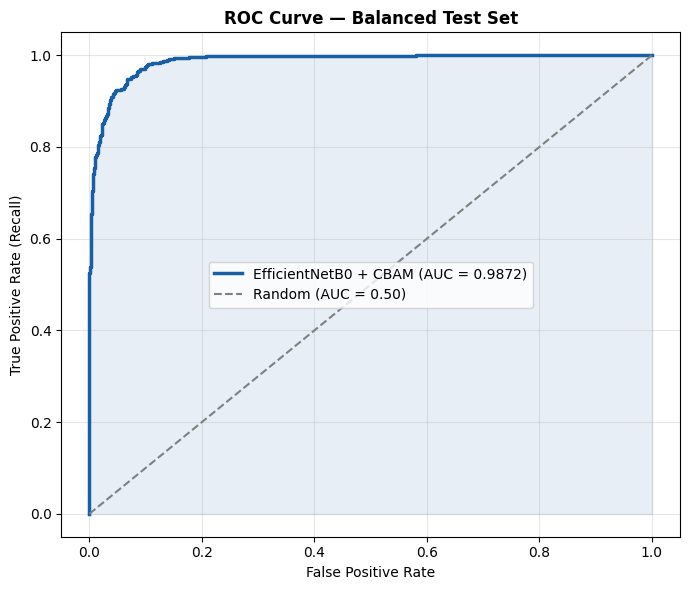

Confusion matrices and ROC curve saved


In [ ]:
# ── Confusion matrix ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrix Comparison', fontsize=14,
             fontweight='bold')

for ax, cm_true, cm_pred, title in zip(
    axes,
    [y_true, y_true_imb],
    [y_pred, y_pred_imb],
    ['Balanced Test (1000:1000)',
     'Imbalanced Test (8000:1000)']
):
    cm = confusion_matrix(cm_true, cm_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names,
                ax=ax, annot_kws={'size': 13, 'weight': 'bold'})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('figure4_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── ROC curve ─────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_true, y_probs)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#185FA5', linewidth=2.5,
        label=f'EfficientNetB0 + CBAM (AUC = {test_auc:.4f})')
ax.plot([0,1],[0,1], 'gray', linestyle='--',
        label='Random (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#185FA5')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve — Balanced Test Set', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figure5_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices and ROC curve saved")

block 17

In [ ]:
print("=" * 65)
print("COMPUTATIONAL ANALYSIS")
print("=" * 65)

# inference time — warm up first then measure 100 runs
dummy  = np.random.rand(1, 128, 128, 3).astype('float32')
_      = model.predict(dummy, verbose=0)

times  = []
for _ in range(100):
    t0 = time.time()
    _  = model.predict(dummy, verbose=0)
    times.append(time.time() - t0)

avg_ms = np.mean(times) * 1000
std_ms = np.std(times)  * 1000

print(f"\nModel Parameters")
print(f"  Total           : {model.count_params():,}")
print(f"\nTraining Time")
print(f"  Phase 1         : {p1_time/60:.1f} minutes")
print(f"  Phase 2         : {p2_time/60:.1f} minutes")
print(f"  Total           : {(p1_time+p2_time)/60:.1f} minutes")
print(f"\nInference Time")
print(f"  Per image       : {avg_ms:.2f} ± {std_ms:.2f} ms")
print(f"  Images/second   : {1000/avg_ms:.1f}")
print(f"  23,000 images   : {23000*avg_ms/1000/60:.1f} minutes")
# save model
model.save('disaster_cbam_final.keras')
print(f"\nFinal model saved: disaster_cbam_final.keras")


COMPUTATIONAL ANALYSIS

Model Parameters
  Total           : 4,808,838

Training Time
  Phase 1         : 11.2 minutes
  Phase 2         : 11.8 minutes
  Total           : 23.0 minutes

Inference Time
  Per image       : 104.62 ± 50.68 ms
  Images/second   : 9.6
  23,000 images   : 40.1 minutes

Final model saved: disaster_cbam_final.keras
